In [1]:
import pandas as pd
import seaborn as sns
from rapidfuzz import process, fuzz

# Process EPC non-domestic

## Column filtering

In [2]:
sample_nd = pd.read_csv("data/epc-nondomestic.csv", nrows=1000)
sample_nd.head()

,certificate_number,address1,address2,address3,posttown,postcode,address,constituency,constituency_label,local_authority,...,building_emissions,aircon_present,aircon_kw_rating,estimated_aircon_kw_rating,ac_inspection_commissioned,building_environment,report_type,primary_energy_value,uprn,uprn_source
0,0000-7404-5801-3694-5935,Rowan House,Hill End Lane,NaN,ST ALBANS,AL4 0RA,"Rowan House, Hill End Lane",E14001507,St Albans,E07000240,...,35.76,No,NaN,NaN,4,Heating and Natural Ventilation,3,221.99,1.000107e+10,Energy Assessor
1,0000-9278-0696-8196-1282,42 George Street,Great Harwood,NaN,BLACKBURN,BB6 7JF,"42 George Street, Great Harwood",E14001299,Hyndburn,E07000120,...,159.05,No,NaN,NaN,4,Heating and Natural Ventilation,3,884.97,1.000104e+11,Energy Assessor
2,0001-2150-4009-1081-1260,251-253 London Road East,Batheaston,NaN,Bath,BA1 7RL,"251-253 London Road East, Batheaston",E14001080,Bath,E06000022,...,69.44,No,NaN,NaN,4,Heating and Natural Ventilation,3,401.12,1.001212e+11,Energy Assessor
3,0001-2823-0043-0321-7174,BLACK HORSE,COVENTRY ROAD,MARTON,CV23 9RH,CV23 9RH,"BLACK HORSE, COVENTRY ROAD, MARTON",E14001309,Kenilworth and Southam,E07000220,...,82.62,No,NaN,NaN,4,Heating and Natural Ventilation,3,614.19,1.001052e+10,Address Matched
4,0001-6857-5728-6832-3157,143 WATER STREET,RADCLIFFE,NaN,RADCLIFFE,M26 3BJ,"143 WATER STREET, RADCLIFFE",E14001145,Bury South,E08000002,...,33.44,No,NaN,NaN,4,Heating and Natural Ventilation,3,193.75,1.000124e+11,Energy Assessor


In [3]:
cols_nd = ["asset_rating_band", 
           "property_type", 
           "lodgement_date",
           "main_heating_fuel",
           "other_fuel_desc",
           "special_energy_uses",
           "renewable_sources",
           "floor_area",
           "asset_rating",
           "inspection_date",
           "standard_emissions",
           "target_emissions",
           "typical_emissions",
           "building_emissions",
           "aircon_present",
           "lodgement_datetime",
           "primary_energy_value",
           "building_level",
           "ac_inspection_commissioned",
           "building_environment",
           "uprn"
           ]
df_nd = pd.read_csv("data/epc-nondomestic.csv", usecols=cols_nd)
df_nd.head()

,asset_rating,asset_rating_band,property_type,inspection_date,lodgement_date,lodgement_datetime,building_level,main_heating_fuel,other_fuel_desc,special_energy_uses,...,floor_area,standard_emissions,target_emissions,typical_emissions,building_emissions,aircon_present,ac_inspection_commissioned,building_environment,primary_energy_value,uprn
0,77,D,Offices and Workshop Businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,1.000107e+10
1,58,C,Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,1.000104e+11
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,1.001212e+11
3,72,C,Restaurants and Cafes/Drinking Establishments/...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,1.001052e+10
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,1.000124e+11


In [4]:
df_nd.columns = df_nd.columns.str.replace("_", " ")
df_nd.columns = df_nd.columns.str.title()
df_nd.columns = df_nd.columns.str.replace(" ", "")
df_nd.head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
0,77,D,Offices and Workshop Businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,1.000107e+10
1,58,C,Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,1.000104e+11
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,1.001212e+11
3,72,C,Restaurants and Cafes/Drinking Establishments/...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,1.001052e+10
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,1.000124e+11


## String matching for PropertyType

In [5]:
df_nd['PropertyType'].nunique()

44

In [6]:
property_type = df_nd['PropertyType'].unique()
print(property_type)

<StringArray>
[                                             'Offices and Workshop Businesses',
                                                                       'Hotels',
                                           'B1 Offices and Workshop businesses',
                      'Restaurants and Cafes/Drinking Establishments/Takeaways',
                             'A1/A2 Retail and Financial/Professional services',
 'A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways',
                                   'Retail/Financial and Professional Services',
                                                                    'C1 Hotels',
               'D1 Non-residential Institutions - Primary Health Care Building',
                             'General Industrial and Special Industrial Groups',
                    'B2 to B7 General Industrial and Special Industrial Groups',
                       'D1 Non-residential Institutions - Community/Day Centre',
              

In [7]:
categories = []
for type in property_type:
        matches = process.extract(type, property_type, scorer=fuzz.ratio, limit=2)

        # Discard self match
        for match, score, _ in matches:
                if type != match:
                    categories.append([type, match])
                    print(type, "|",match)

Offices and Workshop Businesses | B1 Offices and Workshop businesses
Hotels | C1 Hotels
B1 Offices and Workshop businesses | Offices and Workshop Businesses
Restaurants and Cafes/Drinking Establishments/Takeaways | A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways
A1/A2 Retail and Financial/Professional services | Retail/Financial and Professional Services
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways | Restaurants and Cafes/Drinking Establishments/Takeaways
Retail/Financial and Professional Services | A1/A2 Retail and Financial/Professional services
C1 Hotels | Hotels
D1 Non-residential Institutions - Primary Health Care Building | Non-residential Institutions: Primary Health Care Building
General Industrial and Special Industrial Groups | B2 to B7 General Industrial and Special Industrial Groups
B2 to B7 General Industrial and Special Industrial Groups | General Industrial and Special Industrial Groups
D1 Non-residential Insti

In [8]:
df = pd.DataFrame(categories, columns=["prev", "new"])
df = df.sort_values(by="prev", ignore_index=True)
df.head()

,prev,new
0,A1/A2 Retail and Financial/Professional services,Retail/Financial and Professional Services
1,A3/A4/A5 Restaurant and Cafes/Drinking Establi...,Restaurants and Cafes/Drinking Establishments/...
2,B1 Offices and Workshop businesses,Offices and Workshop Businesses
3,B2 to B7 General Industrial and Special Indust...,General Industrial and Special Industrial Groups
4,B8 Storage or Distribution,Storage or Distribution


In [9]:
df = df.drop([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 31, 32, 33, 34, 38])
df = df.reset_index(drop=True)
df.head()

,prev,new
0,"General Assembly and Leisure, Night Clubs, and...",D2 General Assembly and Leisure plus Night Clu...
1,General Industrial and Special Industrial Groups,B2 to B7 General Industrial and Special Indust...
2,Hotels,C1 Hotels
3,Non-residential Institutions: Community/Day Ce...,D1 Non-residential Institutions - Community/Da...
4,Non-residential Institutions: Crown and County...,D1 Non-residential Institutions - Crown and Co...


In [10]:
category_dict = dict(zip(df['prev'], df['new']))
print(category_dict)
print(len(category_dict))

{'General Assembly and Leisure, Night Clubs, and Theatres': 'D2 General Assembly and Leisure plus Night Clubs and Theatres', 'General Industrial and Special Industrial Groups': 'B2 to B7 General Industrial and Special Industrial Groups', 'Hotels': 'C1 Hotels', 'Non-residential Institutions: Community/Day Centre': 'D1 Non-residential Institutions - Community/Day Centre', 'Non-residential Institutions: Crown and County Courts': 'D1 Non-residential Institutions - Crown and County Courts', 'Non-residential Institutions: Education': 'D1 Non-residential Institutions - Education', 'Non-residential Institutions: Libraries, Museums, and Galleries': 'D1 Non-residential Institutions - Libraries Museums and Galleries', 'Non-residential Institutions: Primary Health Care Building': 'D1 Non-residential Institutions - Primary Health Care Building', 'Offices and Workshop Businesses': 'B1 Offices and Workshop businesses', 'Others - Car Parks 24 hrs': 'Others: Car Parks 24 hrs', 'Others - Emergency servi

In [11]:
df_nd["PropertyType"].value_counts()

PropertyType
Retail/Financial and Professional Services                                      130928
Offices and Workshop Businesses                                                 103875
A1/A2 Retail and Financial/Professional services                                 74306
B1 Offices and Workshop businesses                                               59160
Restaurants and Cafes/Drinking Establishments/Takeaways                          48208
Storage or Distribution                                                          37536
General Industrial and Special Industrial Groups                                 24468
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways     23783
B8 Storage or Distribution                                                       22035
B2 to B7 General Industrial and Special Industrial Groups                        13717
General Assembly and Leisure, Night Clubs, and Theatres                           8464
Non-residential Institutions: 

In [12]:
df_nd['PropertyType'] = df_nd['PropertyType'].map(category_dict).fillna(df_nd['PropertyType'])
df_nd.head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
0,77,D,B1 Offices and Workshop businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,1.000107e+10
1,58,C,C1 Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,1.000104e+11
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,1.001212e+11
3,72,C,A3/A4/A5 Restaurant and Cafes/Drinking Establi...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,1.001052e+10
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,1.000124e+11


In [13]:
df_nd["PropertyType"].value_counts()

PropertyType
A1/A2 Retail and Financial/Professional services                                205234
B1 Offices and Workshop businesses                                              163035
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways     71991
B8 Storage or Distribution                                                       59571
B2 to B7 General Industrial and Special Industrial Groups                        38185
D2 General Assembly and Leisure plus Night Clubs and Theatres                    12153
D1 Non-residential Institutions - Education                                      11501
C2 Residential Institutions - Hospitals and Care Homes                           10746
D1 Non-residential Institutions - Primary Health Care Building                   10184
C1 Hotels                                                                         9545
D1 Non-residential Institutions - Community/Day Centre                            7045
C2 Residential Institutions - 

In [14]:
df_nd.describe()

,AssetRating,BuildingLevel,OtherFuelDesc,SpecialEnergyUses,RenewableSources,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,611336.000000,611336.000000,0.0,0.0,0.0,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,5.576430e+05
mean,66.164240,3.170492,NaN,NaN,NaN,713.747252,39.378533,19.207235,64.006295,49.366525,4.081651,342.725177,5.316612e+10
std,32.797109,0.462761,NaN,NaN,NaN,2945.764573,75.863861,62.764767,195.888820,100.150085,0.434229,687.190559,6.453033e+10
min,-8022.000000,3.000000,NaN,NaN,NaN,2.000000,0.540000,-821.390000,-3285.560000,-5841.920000,1.000000,-41131.200000,2.600000e+01
25%,46.000000,3.000000,NaN,NaN,NaN,88.000000,15.180000,3.080000,13.040000,16.220000,4.000000,146.860000,1.000129e+10
50%,63.000000,3.000000,NaN,NaN,NaN,190.000000,25.300000,9.320000,35.020000,33.080000,4.000000,256.250000,1.009075e+10
75%,83.000000,3.000000,NaN,NaN,NaN,471.000000,50.950000,25.650000,82.972500,63.660000,4.000000,432.150000,1.000521e+11
max,2576.000000,5.000000,NaN,NaN,NaN,423710.000000,27057.700000,36311.300000,106407.000000,48063.000000,5.000000,284303.000000,4.220001e+11


In [15]:
df_nd.info()

<class 'pandas.DataFrame'>
RangeIndex: 611336 entries, 0 to 611335
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AssetRating               611336 non-null  int64  
 1   AssetRatingBand           611336 non-null  str    
 2   PropertyType              611336 non-null  str    
 3   InspectionDate            611336 non-null  str    
 4   LodgementDate             611336 non-null  str    
 5   LodgementDatetime         611336 non-null  str    
 6   BuildingLevel             611336 non-null  int64  
 7   MainHeatingFuel           611336 non-null  str    
 8   OtherFuelDesc             0 non-null       float64
 9   SpecialEnergyUses         0 non-null       float64
 10  RenewableSources          0 non-null       float64
 11  FloorArea                 611336 non-null  int64  
 12  StandardEmissions         611336 non-null  float64
 13  TargetEmissions           611336 non-null  float64
 14 

In [16]:
df_nd.dtypes

AssetRating                   int64
AssetRatingBand                 str
PropertyType                    str
InspectionDate                  str
LodgementDate                   str
LodgementDatetime               str
BuildingLevel                 int64
MainHeatingFuel                 str
OtherFuelDesc               float64
SpecialEnergyUses           float64
RenewableSources            float64
FloorArea                     int64
StandardEmissions           float64
TargetEmissions             float64
TypicalEmissions            float64
BuildingEmissions           float64
AirconPresent                   str
AcInspectionCommissioned      int64
BuildingEnvironment             str
PrimaryEnergyValue          float64
Uprn                        float64
dtype: object

In [17]:
df_nd[["OtherFuelDesc", "SpecialEnergyUses", "RenewableSources"]] = df_nd[["OtherFuelDesc", "SpecialEnergyUses", "RenewableSources"]].astype(str)
df_nd["Uprn"] = df_nd["Uprn"].astype("Int64")
df_nd.dtypes

AssetRating                   int64
AssetRatingBand                 str
PropertyType                    str
InspectionDate                  str
LodgementDate                   str
LodgementDatetime               str
BuildingLevel                 int64
MainHeatingFuel                 str
OtherFuelDesc                   str
SpecialEnergyUses               str
RenewableSources                str
FloorArea                     int64
StandardEmissions           float64
TargetEmissions             float64
TypicalEmissions            float64
BuildingEmissions           float64
AirconPresent                   str
AcInspectionCommissioned      int64
BuildingEnvironment             str
PrimaryEnergyValue          float64
Uprn                          Int64
dtype: object

## Stats

In [18]:
df_nd.head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
0,77,D,B1 Offices and Workshop businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,10001072007
1,58,C,C1 Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,100010448217
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,100121173581
3,72,C,A3/A4/A5 Restaurant and Cafes/Drinking Establi...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,10010523213
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,100012438436


In [19]:
df_nd.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,557643.0
mean,66.164240,3.170492,713.747252,39.378533,19.207235,64.006295,49.366525,4.081651,342.725177,53166115580.688812
std,32.797109,0.462761,2945.764573,75.863861,62.764767,195.888820,100.150085,0.434229,687.190559,64530334067.53405
min,-8022.000000,3.000000,2.000000,0.540000,-821.390000,-3285.560000,-5841.920000,1.000000,-41131.200000,26.0
25%,46.000000,3.000000,88.000000,15.180000,3.080000,13.040000,16.220000,4.000000,146.860000,10001289587.5
50%,63.000000,3.000000,190.000000,25.300000,9.320000,35.020000,33.080000,4.000000,256.250000,10090749821.0
75%,83.000000,3.000000,471.000000,50.950000,25.650000,82.972500,63.660000,4.000000,432.150000,100052111703.5
max,2576.000000,5.000000,423710.000000,27057.700000,36311.300000,106407.000000,48063.000000,5.000000,284303.000000,422000142689.0


In [20]:
df_nd["PropertyType"].value_counts()

PropertyType
A1/A2 Retail and Financial/Professional services                                205234
B1 Offices and Workshop businesses                                              163035
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways     71991
B8 Storage or Distribution                                                       59571
B2 to B7 General Industrial and Special Industrial Groups                        38185
D2 General Assembly and Leisure plus Night Clubs and Theatres                    12153
D1 Non-residential Institutions - Education                                      11501
C2 Residential Institutions - Hospitals and Care Homes                           10746
D1 Non-residential Institutions - Primary Health Care Building                   10184
C1 Hotels                                                                         9545
D1 Non-residential Institutions - Community/Day Centre                            7045
C2 Residential Institutions - 

In [21]:
type_retail_financial = df_nd.iloc[df_nd["PropertyType"]=="A1/A2 Retail and Financial/Professional services"]
type_office = df_nd.iloc[df_nd["PropertyType"]=="B1 Offices and Workshop businesses"]
type_restaurant = df_nd.iloc[df_nd["PropertyType"]=="A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways"]
type_storage = df_nd.iloc[df_nd["PropertyType"]=="B8 Storage or Distribution"]
type_education = df_nd.iloc[df_nd["PropertyType"]=="D1 Non-residential Institutions - Education"]
type_hotel = df_nd.iloc[df_nd["PropertyType"]=="C1 Hotels"]

In [22]:
type_retail_financial.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,205234.000000,205234.000000,205234.000000,205234.000000,205234.000000,205234.000000,205234.000000,205234.000000,205234.000000,190205.0
mean,63.847296,3.112545,356.688809,41.334042,17.729819,57.177775,51.518783,4.092553,367.277319,58060702170.84024
std,26.845373,0.365935,1177.241202,83.926205,47.971811,162.174040,80.833939,0.421054,550.255278,63076854341.800743
min,-3740.000000,3.000000,2.000000,0.780000,-552.880000,-2211.500000,-5841.920000,1.000000,-289.350000,3584.0
25%,46.000000,3.000000,63.000000,17.530000,2.890000,12.190000,18.540000,4.000000,183.100000,10000145590.0
50%,61.000000,3.000000,111.000000,24.510000,5.310000,21.620000,31.460000,4.000000,278.755000,10094756049.0
75%,78.000000,3.000000,241.000000,56.360000,28.950000,86.200000,68.977500,4.000000,441.430000,100062302714.0
max,1846.000000,5.000000,148490.000000,20282.100000,7174.080000,28768.100000,10225.100000,5.000000,107542.000000,422000142689.0


In [23]:
type_office.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,163035.000000,163035.000000,163035.000000,163035.000000,163035.000000,163035.000000,163035.000000,163035.000000,163035.000000,145546.0
mean,73.276530,3.188990,658.408409,21.687216,9.709411,32.071080,31.660911,4.087993,221.602407,46508681864.566345
std,34.564774,0.486056,2560.484394,32.715604,20.787131,67.113897,49.203071,0.476528,406.100307,64069628662.105507
min,-1421.000000,3.000000,2.000000,0.540000,-603.830000,-2415.310000,-538.750000,1.000000,-3779.120000,53.0
25%,50.000000,3.000000,98.000000,11.760000,2.390000,10.820000,12.240000,4.000000,114.070000,10002333816.5
50%,71.000000,3.000000,199.000000,17.090000,5.090000,20.130000,23.720000,4.000000,182.150000,10034169875.0
75%,94.000000,3.000000,449.000000,29.340000,16.210000,49.120000,42.810000,4.000000,284.370000,100032122856.0
max,848.000000,5.000000,183748.000000,7963.710000,3390.640000,13596.500000,13272.000000,5.000000,137143.000000,422000141725.0


In [24]:
type_restaurant.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,71991.000000,71991.000000,71991.000000,71991.000000,71991.000000,71991.000000,71991.000000,71991.000000,71991.000000,67681.0
mean,59.507563,3.094762,237.219208,74.527981,38.652711,131.902007,89.893866,4.081524,635.707697,60539197726.107666
std,21.988970,0.328308,257.656909,36.440509,27.925538,79.350181,63.621568,0.412416,347.469833,63645780769.02079
min,-19.000000,3.000000,3.000000,0.830000,-564.300000,-2257.220000,-3.580000,1.000000,-38.550000,1362.0
25%,44.000000,3.000000,83.000000,50.970000,19.820000,79.350000,48.520000,4.000000,423.660000,10000132835.0
50%,58.000000,3.000000,162.000000,68.120000,30.080000,116.350000,70.660000,4.000000,552.580000,10096363756.0
75%,72.000000,3.000000,321.000000,91.950000,52.200000,172.470000,114.965000,4.000000,756.400000,100062309894.0
max,375.000000,5.000000,19053.000000,1653.890000,1641.070000,4809.000000,4145.830000,5.000000,24519.300000,422000142356.0


In [25]:
type_storage.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,59571.000000,59571.000000,59571.000000,59571.000000,59571.000000,59571.000000,59571.000000,59571.000000,59571.000000,53280.0
mean,65.880949,3.259069,1744.659599,19.647111,10.268132,33.236590,26.647994,4.051988,178.631544,43899969437.589043
std,47.725004,0.593326,6438.698570,28.437447,23.922297,71.482731,38.974430,0.346885,268.531091,65892624848.438637
min,-8022.000000,3.000000,2.000000,0.540000,-8.500000,-33.990000,-3528.120000,1.000000,-41131.200000,70.0
25%,47.000000,3.000000,175.000000,5.320000,1.470000,6.600000,5.660000,4.000000,57.720000,10002323608.0
50%,64.000000,3.000000,418.000000,12.310000,4.060000,17.140000,13.600000,4.000000,118.030000,10070378199.5
75%,85.000000,3.000000,1069.000000,28.710000,16.460000,50.990000,41.080000,4.000000,258.925000,100023302786.0
max,847.000000,5.000000,281059.000000,4804.660000,4744.170000,13902.300000,3969.590000,5.000000,22431.400000,422000141862.0


In [26]:
type_education.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,11501.000000,11501.000000,11501.000000,11501.000000,11501.000000,11501.000000,11501.000000,11501.000000,11501.000000,10496.0
mean,56.907834,3.458395,843.660290,25.356049,13.356993,45.246402,28.191680,4.054169,186.875341,58870959204.627953
std,35.658223,0.695035,1658.164183,24.567454,18.342135,58.462274,33.883972,0.516615,239.601290,66791942265.556694
min,-92.000000,3.000000,8.000000,1.140000,-0.590000,-2.370000,-48.640000,1.000000,-360.470000,1434.0
25%,29.000000,3.000000,165.000000,18.610000,5.920000,23.920000,13.490000,4.000000,97.320000,10002701632.25
50%,57.000000,3.000000,332.000000,22.110000,12.260000,41.050000,23.800000,4.000000,164.710000,10093563849.0
75%,80.000000,4.000000,766.000000,26.380000,15.940000,52.190000,36.140000,4.000000,230.390000,100062474915.5
max,417.000000,5.000000,32656.000000,658.670000,493.700000,1650.750000,1564.320000,5.000000,17030.400000,422000127010.0


In [27]:
type_hotel.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,9545.000000,9545.000000,9545.000000,9545.000000,9545.000000,9545.000000,9545.000000,9545.000000,9545.000000,8965.0
mean,54.091671,3.234468,1801.999162,101.354502,60.627594,215.459584,108.631958,4.036878,673.797498,58172976459.47998
std,33.865936,0.536128,3739.716631,38.624403,41.324706,126.444817,86.346224,0.480009,475.473193,61737242748.320122
min,-23.000000,3.000000,5.000000,2.010000,0.000000,0.080000,-81.790000,1.000000,-932.680000,4233.0
25%,40.000000,3.000000,265.000000,83.980000,43.940000,167.730000,71.500000,4.000000,498.010000,10006531268.0
50%,52.000000,3.000000,537.000000,98.670000,57.470000,210.930000,99.930000,4.000000,633.990000,10093393216.0
75%,64.000000,3.000000,1624.000000,116.740000,74.080000,252.510000,133.910000,4.000000,794.560000,100061145696.0
max,2576.000000,5.000000,65410.000000,998.730000,2650.640000,7767.430000,6234.070000,5.000000,35223.700000,422000113456.0


In [28]:
# 5 outliers with primary energy value > 5000
type_hotel.iloc[type_hotel["PrimaryEnergyValue"] > 5000].head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
49768,2576,G,C1 Hotels,2020-08-17,2020-08-26,2020-08-26 23:29:49,3,Natural Gas,NaN,NaN,...,360,121.01,2650.64,7767.43,6234.07,No,4,Heating and Natural Ventilation,35223.70,5003983
100334,52,C,C1 Hotels,2021-10-18,2021-10-22,2021-10-22 14:04:35,3,Natural Gas,NaN,NaN,...,85,998.73,697.05,2042.64,1038.35,No,4,Heating and Natural Ventilation,5916.41,10012100252
111068,70,C,C1 Hotels,2020-08-28,2020-09-09,2020-09-15 17:12:42,3,Grid Supplied Electricity,NaN,NaN,...,36,705.68,683.55,2003.08,987.71,Yes,4,Air Conditioning,5842.51,34139084
369470,69,C,C1 Hotels,2021-10-08,2021-10-08,2021-10-11 07:52:41,3,Grid Supplied Electricity,NaN,NaN,...,95,639.67,611.79,1792.81,877.83,No,4,Heating and Natural Ventilation,5181.20,200001586863
569652,50,B,C1 Hotels,2021-10-18,2021-10-22,2021-10-22 13:51:28,3,Natural Gas,NaN,NaN,...,76,988.34,673.84,1974.61,980.10,No,4,Heating and Natural Ventilation,5571.80,10012100252


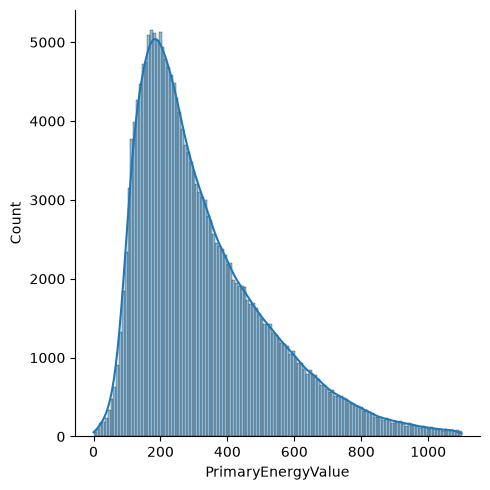

In [29]:
retail_outliers_removed = type_retail_financial.iloc[(type_retail_financial["PrimaryEnergyValue"] < 1100) & (type_retail_financial["PrimaryEnergyValue"] > 0)]
sns.displot(data=retail_outliers_removed["PrimaryEnergyValue"], kde=True)

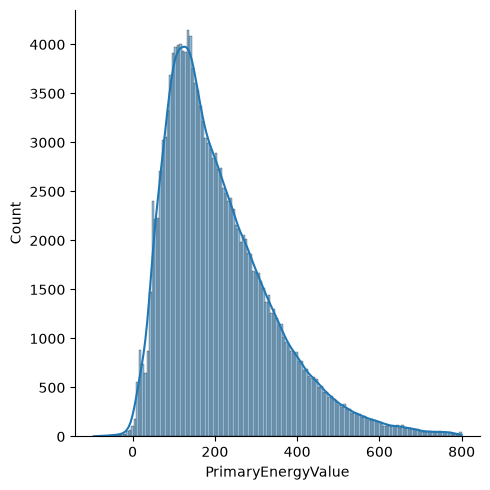

In [30]:
office_outliers_removed = type_office.iloc[(type_office["PrimaryEnergyValue"] < 800) & (type_office["PrimaryEnergyValue"] > -100)]
sns.displot(data=office_outliers_removed["PrimaryEnergyValue"], kde=True)

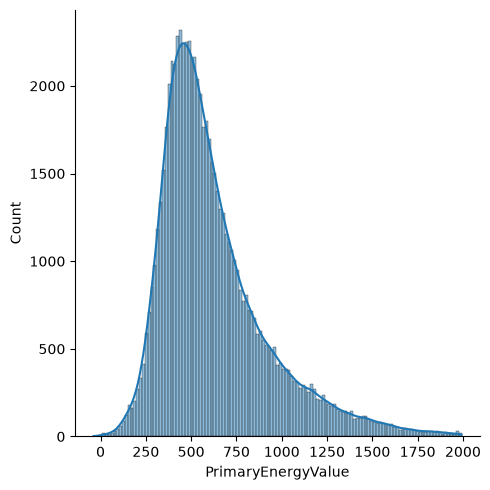

In [31]:
restaurant_outliers_removed = type_restaurant.iloc[type_restaurant["PrimaryEnergyValue"] < 2000]
sns.displot(data=restaurant_outliers_removed["PrimaryEnergyValue"], kde=True)

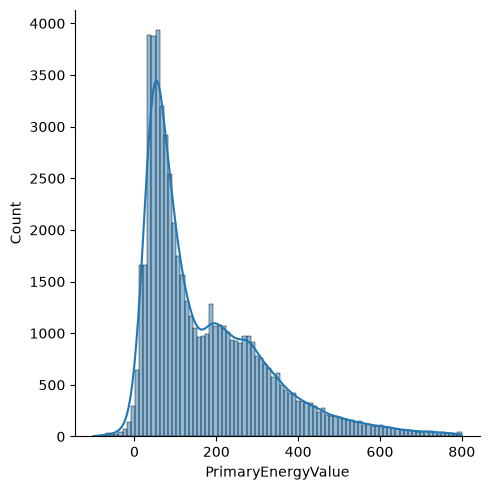

In [32]:
storage_outliers_removed = type_storage.iloc[(type_storage["PrimaryEnergyValue"] < 800) & (type_storage["PrimaryEnergyValue"] > -100)]
sns.displot(data=storage_outliers_removed["PrimaryEnergyValue"], kde=True)

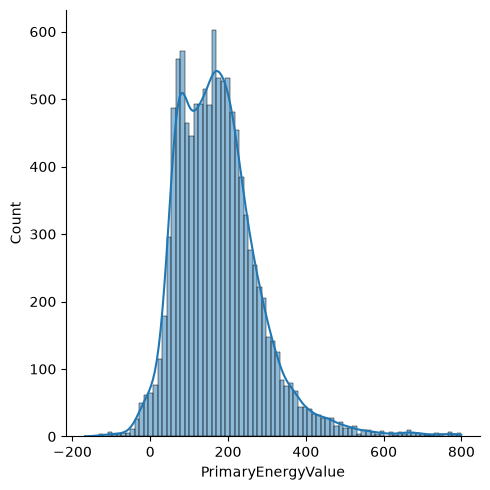

In [33]:
education_outliers_removed = type_education.iloc[(type_education["PrimaryEnergyValue"] < 800) & (type_education["PrimaryEnergyValue"] > -200)]
sns.displot(data=education_outliers_removed["PrimaryEnergyValue"], kde=True)

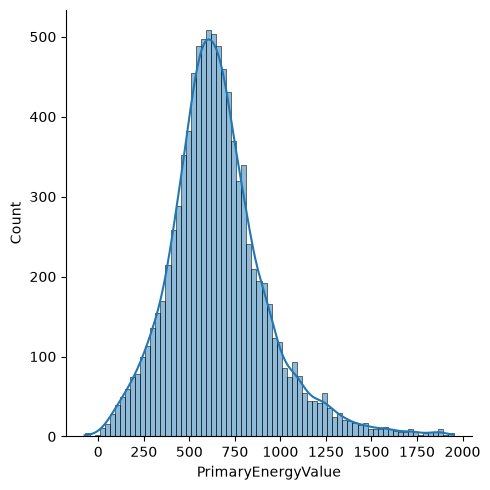

In [ ]:
hotel_outliers_removed = type_hotel.iloc[(type_hotel["PrimaryEnergyValue"] < 2000) & (type_hotel["PrimaryEnergyValue"] > -200)]
sns.displot(data=hotel_outliers_removed["PrimaryEnergyValue"], kde=True)

# Process EPC domestic

In [35]:
sample_domestic = pd.read_csv("data/epc-domestic.csv", nrows=1000)
sample_domestic.head()

,certificate_number,address1,address2,address3,postcode,posttown,address,constituency,constituency_label,local_authority,...,walls_env_eff,wind_turbine_count,windows_description,windows_energy_eff,windows_env_eff,floor_env_eff,region,country,uprn,uprn_source
0,0000-0467-0622-8297-3123,149 Wilmington Gardens,NaN,NaN,IG11 9TT,BARKING,149 Wilmington Gardens,E14001073,Barking,E09000002,...,Very Poor,0.0,Fully double glazed,Good,Good,NaN,E12000007,England,1.000510e+08,Energy Assessor
1,0000-1023-0922-4029-3103,118 BRUDENELL ROAD,HYDE PARK,NaN,LS6 1LS,LEEDS,"118 BRUDENELL ROAD, HYDE PARK",E14001319,Leeds Central and Headingley,E08000035,...,Poor,0.0,Fully double glazed,Average,Average,NaN,E12000003,England,7.203190e+07,Energy Assessor
2,0000-1051-0332-5101-3853,1602,2 William Jessop Way,NaN,L3 1EY,Liverpool,"1602, 2 William Jessop Way",E14001338,Liverpool Riverside,E08000012,...,Average,0.0,High performance glazing,Very Good,Very Good,NaN,E12000002,England,3.835019e+07,Address Matched
3,0000-1116-0432-2492-3343,44 Bromford Road,NaN,NaN,B69 4BH,OLDBURY,44 Bromford Road,E14001574,West Bromwich,E08000028,...,Very Good,0.0,High performance glazing,Very Good,Very Good,NaN,E12000005,England,1.009617e+10,Energy Assessor
4,0000-1154-0622-0107-3853,26 Melrose Avenue Woodfield,Road Sparkbrook,NaN,B12 8UH,Birmingham,"26 Melrose Avenue Woodfield, Road Sparkbrook",E14001094,Birmingham Hall Green and Moseley,E08000025,...,Very Poor,0.0,Fully double glazed,Poor,Poor,NaN,E12000005,England,NaN,NaN


In [36]:
sample_domestic.dtypes

certificate_number        str
address1                  str
address2                  str
address3                  str
postcode                  str
                       ...   
floor_env_eff             str
region                    str
country                   str
uprn                  float64
uprn_source               str
Length: 93, dtype: object

In [37]:
sample_domestic.describe()

,co2_emiss_curr_per_floor_area,co2_emissions_current,co2_emissions_potential,current_energy_efficiency,energy_consumption_current,energy_consumption_potential,environment_impact_current,environment_impact_potential,extension_count,fixed_lighting_outlets_count,...,number_open_fireplaces,photo_supply,potential_energy_efficiency,report_type,sheating_energy_eff,sheating_env_eff,total_floor_area,unheated_corridor_length,wind_turbine_count,uprn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,900.000000,1000.00000,...,984.000000,888.000000,1000.000000,1000.00000,0.0,0.0,1000.000000,165.000000,991.000000,9.920000e+02
mean,41.413900,3.300500,1.832300,67.636000,235.479000,135.487000,65.701000,79.620000,0.445556,11.19200,...,0.053862,0.737613,81.483000,2.10000,NaN,NaN,83.762000,5.772976,0.001009,3.113743e+10
std,21.035396,2.348354,1.312093,12.188522,122.945944,85.529592,14.394749,9.661001,0.746018,7.78394,...,0.322354,5.233215,7.654953,0.30015,NaN,NaN,49.956752,2.664578,0.031766,5.372695e+10
min,1.800000,0.200000,-1.300000,1.000000,13.000000,-105.000000,6.000000,26.000000,0.000000,1.00000,...,0.000000,0.000000,16.000000,2.00000,NaN,NaN,13.000000,0.800000,0.000000,3.253600e+04
25%,29.000000,1.875000,1.100000,62.000000,164.750000,88.000000,57.000000,75.000000,0.000000,7.00000,...,0.000000,0.000000,78.000000,2.00000,NaN,NaN,57.000000,4.100000,0.000000,6.309718e+07
50%,38.000000,2.800000,1.600000,69.000000,214.000000,118.000000,67.000000,81.000000,0.000000,10.00000,...,0.000000,0.000000,82.000000,2.00000,NaN,NaN,75.000000,5.580000,0.000000,1.000260e+10
75%,50.000000,4.100000,2.200000,75.000000,281.250000,161.000000,75.000000,85.000000,1.000000,13.00000,...,0.000000,0.000000,86.000000,2.00000,NaN,NaN,96.000000,7.230000,0.000000,1.009606e+10
max,170.000000,31.000000,15.000000,97.000000,1005.000000,650.000000,98.000000,115.000000,4.000000,100.00000,...,6.000000,60.000000,116.000000,3.00000,NaN,NaN,661.000000,15.270000,1.000000,4.220001e+11


In [ ]:
cols_d = ['current_energy_rating',
          'property_type',
          'built_form',
          'lodgement_date',
          'total_floor_area',
          'floor_level',
          'flat_top_storey',
          'number_habitable_rooms',
          'floor_description',
          'windows_description',
          'walls_description',
          'roof_description',
          'mainheat_description',
          'photo_supply',
          'tenure',
          'potential_energy_rating',
          'current_energy_efficiency',
          'potential_energy_efficiency',
          'inspection_date',
          'main_fuel',
          'environment_impact_current',
          'environment_impact_potential',
          'energy_consumption_current',
          'energy_consumption_potential',
          'co2_emissions_current',
          'co2_emiss_curr_per_floor_area',
          'co2_emissions_potential',
          'floor_height',
          'extension_count',
          'number_open_fireplaces',
          'energy_tariff',
          'mains_gas_flag',
          'mechanical_ventilation',
          'uprn',
          'construction_age_band']